# Gradient Singular Spectrum & Subspace Conflict Study

This notebook compares gradient geometry between:
- **Safety patch data** (default: `oneshotpatch`)
- **Utility medical data mixtures** using `n` datasets per batch (batch size = 16)

Outputs:
1. Singular value spectra for safety vs utility mixtures
2. Top-`k` subspace overlap/conflict using a Frobenius overlap metric

Dataset loading and formatting reuse functions from `utils/process_dataset.py`.

In [1]:

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, PeftModel, get_peft_model

from utils.process_dataset import get_whole_dataset, process_sft_dataset

SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
# print(f"Using device: {device}")

# device = 'cpu'

[2026-02-22 15:19:33,767] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)


comet_ml is installed but `COMET_API_KEY` is not set.


In [2]:
@dataclass
class StudyConfig:
    model_name_or_path: str = "meta-llama/Llama-2-7b-chat-hf"
    # existing_lora_path: str = "/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_krum_c10s10_i10_b16a1_l512_r32a64_20260212154647/checkpoint-30"  # set to adapter/checkpoint path; empty -> create fresh LoRA
    # existing_lora_path: str = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r64a128_20260218190209/checkpoint-30'
    existing_lora_path: str = '/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r128a256_20260219071754/checkpoint-30'
    local_data_dir: str = None

    template: str = "chat"
    max_length: int = 512
    batch_size: int = 4

    safety_dataset_name: str = "oneshotpatch"
    safety_pool_size: int = 1

    utility_dataset_names: List[str] = None
    utility_pool_per_dataset: int = 16
    utility_n_values: List[int] = None

    safety_eval_size: int = 4
    utility_eval_size_total: int = 4
    grad_aggregation: str = "single_batch"  # single_batch | mean_over_batches
    matrix_only: bool = True  # keep only matrix-shaped trainable params (d_out x d_in)
    clear_cuda_cache_each_batch: bool = False  # set True only if you still hit OOM; can reduce speed

    k_values: List[int] = None

    load_in_8bit: bool = True
    torch_dtype = torch.bfloat16

    lora_r: int = 32
    lora_alpha: int = 64
    lora_dropout: float = 0.05
    lora_target_modules: List[str] = None


cfg = StudyConfig()
if cfg.utility_dataset_names is None:
    cfg.utility_dataset_names = ["qiaojin/PubMedQA", "medQA", "emrqa", "cord19" ]
    # cfg.utility_dataset_names = ['qiaojin/PubMedQA', 'rajpurkar/squad_v2']
if cfg.utility_n_values is None:
    # cfg.utility_n_values = [1, 2]
    cfg.utility_n_values = [1, 2, 3, 4]

if cfg.k_values is None:
    cfg.k_values = [1, 2, 4, 8, 12, 16]
if cfg.lora_target_modules is None:
    cfg.lora_target_modules = ["q_proj", "v_proj"]

assert max(cfg.utility_n_values) <= len(cfg.utility_dataset_names), "utility_n_values exceeds utility dataset count"
assert cfg.grad_aggregation in ["single_batch", "mean_over_batches"], "grad_aggregation must be single_batch or mean_over_batches"
print(cfg)

StudyConfig(model_name_or_path='meta-llama/Llama-2-7b-chat-hf', existing_lora_path='/scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r128a256_20260219071754/checkpoint-30', local_data_dir=None, template='chat', max_length=512, batch_size=4, safety_dataset_name='oneshotpatch', safety_pool_size=1, utility_dataset_names=['qiaojin/PubMedQA', 'medQA', 'emrqa', 'cord19'], utility_pool_per_dataset=16, utility_n_values=[1, 2, 3, 4], safety_eval_size=4, utility_eval_size_total=4, grad_aggregation='single_batch', matrix_only=True, clear_cuda_cache_each_batch=False, k_values=[1, 2, 4, 8, 12, 16], load_in_8bit=True, lora_r=32, lora_alpha=64, lora_dropout=0.05, lora_target_modules=['q_proj', 'v_proj'])


In [3]:
def build_model_and_tokenizer(cfg: StudyConfig):
    hf_token = os.environ.get("HUGGINGFACE_HUB_TOKEN", None)

    tokenizer = AutoTokenizer.from_pretrained(
        cfg.model_name_or_path,
        use_fast=False,
        padding_side="right",
        use_auth_token=hf_token,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.unk_token

    model_kwargs = {
        "use_auth_token": hf_token,
        "trust_remote_code": False,
    }

    if cfg.torch_dtype != "auto":
        model_kwargs["torch_dtype"] = cfg.torch_dtype

    if cfg.load_in_8bit and torch.cuda.is_available():
        model_kwargs["load_in_8bit"] = True
        model_kwargs["device_map"] = "auto"

    model = AutoModelForCausalLM.from_pretrained(cfg.model_name_or_path, **model_kwargs)

    if cfg.existing_lora_path and Path(cfg.existing_lora_path).exists():
        model = PeftModel.from_pretrained(model, cfg.existing_lora_path, is_trainable=True)
        print(f"Loaded existing LoRA from: {cfg.existing_lora_path}")
    else:
        peft_config = LoraConfig(
            r=cfg.lora_r,
            lora_alpha=cfg.lora_alpha,
            lora_dropout=cfg.lora_dropout,
            bias="none",
            task_type="CAUSAL_LM",
            target_modules=cfg.lora_target_modules,
        )
        
        model = get_peft_model(model, peft_config)
        print("No existing LoRA set, initialized fresh PEFT adapter config.")

    model.train()
    # if not cfg.load_in_8bit or not torch.cuda.is_available():
    #     model = model.to(device)
    model = model.to(device)
    

    model.print_trainable_parameters()
    return model, tokenizer


model, tokenizer = build_model_and_tokenizer(cfg)

/home/ps9044/miniconda3/envs/fedllmold/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Using pad_token, but it is not set yet.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded existing LoRA from: /scratch/ps9044/newsetting/PubMedQA7_BeaverTails3_500_fedavg_c10s10_i10_b16a1_l512_r128a256_20260219071754/checkpoint-30
trainable params: 67,108,864 || all params: 6,805,524,480 || trainable%: 0.986093932910223


In [4]:
model.device

device(type='cuda', index=0)

In [5]:
not cfg.load_in_8bit or not torch.cuda.is_available()

False

In [6]:
count = 0
for n,p in model.named_parameters():
    if p.requires_grad:
        print(n, p.data.shape)
        count+=1
print(count)


base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight torch.Size([128, 4096])
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight torch.Size([4096, 128])
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight torch.Size([128, 4096])
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight torch.Size([4096, 128])
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight torch.Size([128, 4096])
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight torch.Size([4096, 128])
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight torch.Size([128, 4096])
base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight torch.Size([4096, 128])
base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight torch.Size([128, 4096])
base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight torch.Size([4096, 128])
base_model.model.model.layers.2.self_attn.v_proj.l

In [7]:
def load_processed_dataset(dataset_name: str, cfg: StudyConfig, sample_count: int, is_benign: bool):
    raw = get_whole_dataset(dataset_name, local_data_dir=cfg.local_data_dir)
    ds = process_sft_dataset(
        dataset_name=dataset_name,
        dataset=raw,
        template_name=cfg.template,
        dataset_sample=sample_count,
        is_benign=is_benign,
        inverse=False,
        tokenizer=tokenizer,
    )
    return ds


safety_ds = load_processed_dataset(
    dataset_name=cfg.safety_dataset_name,
    cfg=cfg,
    sample_count=cfg.safety_pool_size,
    is_benign=False,
)

utility_ds_map: Dict[str, object] = {}
for ds_name in cfg.utility_dataset_names:
    utility_ds_map[ds_name] = load_processed_dataset(
        dataset_name=ds_name,
        cfg=cfg,
        sample_count=cfg.utility_pool_per_dataset,
        is_benign=True,
    )

print(f"Safety pool size: {len(safety_ds)}")
for name, ds in utility_ds_map.items():
    print(f"Utility pool {name}: {len(ds)}")

Preprocessing oneshotpatch for unified format.:   0%|          | 0/1 [00:00<?, ? examples/s]

Converting oneshotpatch to chat format:   0%|          | 0/1 [00:00<?, ? examples/s]

Formatting chat messages into single string prompts:   0%|          | 0/1 [00:00<?, ? examples/s]

>> ===== After processing, Dataset oneshotpatch has 1 examples. =====


Preprocessing qiaojin/PubMedQA for unified format.:   0%|          | 0/211269 [00:00<?, ? examples/s]

...

>> ===== After processing, Dataset medQA has 16 examples. =====


Found cached dataset parquet (/home/ps9044/.cache/huggingface/datasets/Eladio___parquet/Eladio--emrqa-msquad-c828ba57b1d8f6c1/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7)
Loading cached processed dataset at /home/ps9044/.cache/huggingface/datasets/Eladio___parquet/Eladio--emrqa-msquad-c828ba57b1d8f6c1/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7/cache-e5021cd7d7e0a45f.arrow
Loading cached processed dataset at /home/ps9044/.cache/huggingface/datasets/Eladio___parquet/Eladio--emrqa-msquad-c828ba57b1d8f6c1/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7/cache-6bd42295da44c141.arrow
Loading cached processed dataset at /home/ps9044/.cache/huggingface/datasets/Eladio___parquet/Eladio--emrqa-msquad-c828ba57b1d8f6c1/0.0.0/14a00e99c0d15a23649d0db8944380ac81082d4b021f398733dd84f3a6c569a7/cache-27b6e47e311420c4.arrow
Loading cached shuffled indices for dataset at /home/ps9044/.cache/huggingface/datasets/Eladio___parquet/E

>> ===== After processing, Dataset emrqa has 16 examples. =====


Found cached dataset json (/home/ps9044/.cache/huggingface/datasets/medalpaca___json/medalpaca--medical_meadow_cord19-5e99d4cd295dd3b8/0.0.0/e347ab1c932092252e717ff3f949105a4dd28b27e842dd53157d2f72e276c2e4)
Loading cached shuffled indices for dataset at /home/ps9044/.cache/huggingface/datasets/medalpaca___json/medalpaca--medical_meadow_cord19-5e99d4cd295dd3b8/0.0.0/e347ab1c932092252e717ff3f949105a4dd28b27e842dd53157d2f72e276c2e4/cache-2542a417351b4ce9.arrow
Loading cached processed dataset at /home/ps9044/.cache/huggingface/datasets/medalpaca___json/medalpaca--medical_meadow_cord19-5e99d4cd295dd3b8/0.0.0/e347ab1c932092252e717ff3f949105a4dd28b27e842dd53157d2f72e276c2e4/cache-d317b714d4c64e52.arrow
Loading cached processed dataset at /home/ps9044/.cache/huggingface/datasets/medalpaca___json/medalpaca--medical_meadow_cord19-5e99d4cd295dd3b8/0.0.0/e347ab1c932092252e717ff3f949105a4dd28b27e842dd53157d2f72e276c2e4/cache-fa0cc0dfbd816a5d.arrow
Loading cached processed dataset at /home/ps9044/.

>> ===== After processing, Dataset cord19 has 16 examples. =====
Safety pool size: 1
Utility pool qiaojin/PubMedQA: 16
Utility pool medQA: 16
Utility pool emrqa: 16
Utility pool cord19: 16


In [8]:
def example_to_text(example: dict) -> str:
    if "formatted_chat" in example:
        return example["formatted_chat"]

    instruction = example.get("instruction", "")
    response = example.get("response", "")
    inp = example.get("input", "")
    if inp:
        instruction = f"{instruction}\n{inp}"

    return f"### Instruction:\n{instruction}\n\n### Response:\n{response}"


def sample_texts_from_dataset(ds, num_texts: int, rng: np.random.Generator) -> List[str]:
    idx = rng.choice(len(ds), size=num_texts, replace=(len(ds) < num_texts))
    return [example_to_text(ds[int(i)]) for i in idx]


def sample_mixed_utility_texts(
    utility_ds_map: Dict[str, object],
    selected_names: List[str],
    total_texts: int,
    rng: np.random.Generator,
) -> List[str]:
    n = len(selected_names)
    base = total_texts // n
    rem = total_texts % n

    counts = [base + (1 if i < rem else 0) for i in range(n)]
    texts = []
    for name, count in zip(selected_names, counts):
        texts.extend(sample_texts_from_dataset(utility_ds_map[name], count, rng))

    rng.shuffle(texts)
    return texts


def chunk_list(items: List[str], chunk_size: int):
    for i in range(0, len(items), chunk_size):
        yield items[i:i + chunk_size]


def get_trainable_param_map(model, matrix_only: bool = True):
    params = []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if matrix_only and p.ndim != 2:
            continue
        params.append((name, p))
    return params


def condition_gradient_by_parameter(
    model,
    tokenizer,
    texts: List[str],
    max_length: int,
    batch_size: int,
    aggregation: str = "mean_over_batches",
    matrix_only: bool = True,
    clear_cuda_cache: bool = False,
) -> Dict[str, torch.Tensor]:
    trainable_params = get_trainable_param_map(model, matrix_only=matrix_only)
    grad_acc = {name: torch.zeros_like(p, dtype=torch.float32, device="cpu") for name, p in trainable_params}

    num_batches = 0
    for text_batch in chunk_list(texts, batch_size):
        encoded = tokenizer(
            text_batch,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_tensors="pt",
        )
        encoded = {k: v.to(device, non_blocking=True) for k, v in encoded.items()}
        labels = encoded["input_ids"].clone()
        print("input_ids device:", encoded["input_ids"].device)
        print("embed weight device:", model.get_input_embeddings().weight.device)

        model.zero_grad(set_to_none=True)
        outputs = model(**encoded, labels=labels)
        loss = outputs.loss
        loss.backward()

        for name, p in trainable_params:
            g = p.grad
            if g is None:
                continue
            grad_acc[name] += g.detach().float().cpu()

        num_batches += 1

        del loss
        del outputs
        del labels
        del encoded
        del g

        if torch.cuda.is_available() and clear_cuda_cache:
            torch.cuda.empty_cache()

        if aggregation == "single_batch":
            break

    if aggregation == "mean_over_batches" and num_batches > 0:
        inv = 1.0 / float(num_batches)
        for name in grad_acc:
            grad_acc[name] *= inv

    model.zero_grad(set_to_none=True)
    return grad_acc


def singular_values_per_parameter(G_by_param: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {name: torch.linalg.svdvals(G.float()) for name, G in G_by_param.items()}


def spectrum_breadth_metrics(svals: torch.Tensor, eps: float = 1e-12):
    s = svals.float()
    s = s[s > eps]
    if s.numel() == 0:
        return {"rank": 0, "effective_rank": 0.0, "s1_over_sum": 1.0}

    p = s / s.sum()
    entropy = -(p * torch.log(p + eps)).sum().item()
    effective_rank = float(math.exp(entropy))
    s1_over_sum = float((s[0] / s.sum()).item())
    return {
        "rank": int(s.numel()),
        "effective_rank": effective_rank,
        "s1_over_sum": s1_over_sum,
    }


def build_left_subspace_cache(G_by_param: Dict[str, torch.Tensor], eps: float = 1e-10):
    cache = {}
    for name, G in G_by_param.items():
        U, S, _ = torch.linalg.svd(G.float(), full_matrices=False)
        rank = int((S > eps).sum().item())
        cache[name] = {
            "U": U.cpu(),
            "rank": rank,
        }
    return cache


def overlap_from_cached_left_subspaces(
    safety_cache: Dict[str, Dict[str, torch.Tensor]],
    utility_cache: Dict[str, Dict[str, torch.Tensor]],
    param_name: str,
    k: int = None,
):
    Us = safety_cache[param_name]["U"]
    Uu = utility_cache[param_name]["U"]
    rs = int(safety_cache[param_name]["rank"])
    ru = int(utility_cache[param_name]["rank"])

    if rs == 0 or ru == 0:
        return 0.0, 0.0, rs, ru, 0

    if k is None:
        k_eff = min(rs, ru)
    else:
        k_eff = min(int(k), rs, ru)

    if k_eff <= 0:
        return 0.0, 0.0, rs, ru, 0

    Us_k = Us[:, :k_eff]
    Uu_k = Uu[:, :k_eff]

    numer = torch.norm(Us_k.T @ Uu_k, p="fro").pow(2).item()
    overlap = numer / float(k_eff)
    # overlap = float(max(0.0, min(1.0, overlap)))
    conflict = overlap
    return overlap, overlap, rs, ru, k_eff

In [9]:
rng = np.random.default_rng(SEED)

# Safety condition gradient (same shape as each trainable parameter matrix)
safety_texts = [sample_texts_from_dataset(safety_ds, cfg.safety_eval_size, rng)[0]]
G_safety_by_param = condition_gradient_by_parameter(
    model=model,
    tokenizer=tokenizer,
    texts=safety_texts,
    max_length=cfg.max_length,
    batch_size=1,
    aggregation=cfg.grad_aggregation,
    matrix_only=cfg.matrix_only,
    clear_cuda_cache=cfg.clear_cuda_cache_each_batch,
)

input_ids device: cuda:0
embed weight device: cuda:0


/home/ps9044/miniconda3/envs/fedllmold/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [10]:
G_safety_by_param['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight'].shape

torch.Size([128, 4096])

In [11]:

S_safety_by_param = singular_values_per_parameter(G_safety_by_param)
safety_subspace_cache = build_left_subspace_cache(G_safety_by_param)

param_spectra_by_condition = {"safety": S_safety_by_param}
rows_overlap = []
rows_breadth = []

for pname, svals in S_safety_by_param.items():
    m = spectrum_breadth_metrics(svals)
    rows_breadth.append({
        "condition": "safety",
        "utility_n": 0,
        "param": pname,
        "rank": m["rank"],
        "effective_rank": m["effective_rank"],
        "s1_over_sum": m["s1_over_sum"],
    })

for n in cfg.utility_n_values:
    # print(cfg.utility_dataset_names[:n])
    selected = [cfg.utility_dataset_names[n-1]]

    # selected = cfg.utility_dataset_names[:n]
    utility_texts = sample_mixed_utility_texts(
        utility_ds_map=utility_ds_map,
        selected_names=selected,
        total_texts=cfg.utility_eval_size_total,
        rng=rng,
    )
    G_util_by_param = condition_gradient_by_parameter(
        model=model,
        tokenizer=tokenizer,
        texts=utility_texts,
        max_length=cfg.max_length,
        batch_size=cfg.batch_size,
        aggregation=cfg.grad_aggregation,
        matrix_only=cfg.matrix_only,
        clear_cuda_cache=cfg.clear_cuda_cache_each_batch,
    )
    S_util_by_param = singular_values_per_parameter(G_util_by_param)
    util_subspace_cache = build_left_subspace_cache(G_util_by_param)

    key = f"utility_n={n}"
    param_spectra_by_condition[key] = S_util_by_param

    common_params = sorted(set(safety_subspace_cache.keys()) & set(util_subspace_cache.keys()))

    for pname in common_params:
        overlap_full, conflict_full, rank_s, rank_u, k_used_full = overlap_from_cached_left_subspaces(
            safety_subspace_cache, util_subspace_cache, pname, k=None
        )
        rows_overlap.append({
            "utility_n": n,
            "datasets": ",".join(selected),
            "param": pname,
            "k_requested": "full",
            "k_used": k_used_full,
            "rank_s": rank_s,
            "rank_u": rank_u,
            "overlap": overlap_full,
            "conflict": conflict_full,
        })

        for k in cfg.k_values:
            overlap_k, conflict_k, rank_s, rank_u, k_eff = overlap_from_cached_left_subspaces(
                safety_subspace_cache, util_subspace_cache, pname, k=k
            )
            rows_overlap.append({
                "utility_n": n,
                "datasets": ",".join(selected),
                "param": pname,
                "k_requested": k,
                "k_used": k_eff,
                "rank_s": rank_s,
                "rank_u": rank_u,
                "overlap": overlap_k,
                "conflict": conflict_k,
            })

    for pname, svals in S_util_by_param.items():
        m = spectrum_breadth_metrics(svals)
        rows_breadth.append({
            "condition": key,
            "utility_n": n,
            "param": pname,
            "rank": m["rank"],
            "effective_rank": m["effective_rank"],
            "s1_over_sum": m["s1_over_sum"],
        })
    
    del G_util_by_param
    del S_util_by_param
    del util_subspace_cache
    if torch.cuda.is_available() and cfg.clear_cuda_cache_each_batch:
        torch.cuda.empty_cache()

overlap_df = pd.DataFrame(rows_overlap)
breadth_df = pd.DataFrame(rows_breadth)

summary_overlap_df = (
    overlap_df.groupby(["utility_n", "k_requested"], as_index=False)
    .agg(
        mean_overlap=("overlap", "mean"),
        mean_conflict=("conflict", "mean"),
        median_overlap=("overlap", "median"),
        median_conflict=("conflict", "median"),
    )
)

print("Gradient aggregation mode:", cfg.grad_aggregation)
print("Matrix-only parameters:", cfg.matrix_only)
print("Clear CUDA cache each batch:", cfg.clear_cuda_cache_each_batch)
print("Safety texts:", len(safety_texts), "Utility texts total per n:", cfg.utility_eval_size_total)
print("Parameter-wise overlap rows:", len(overlap_df))
print("Parameter-wise breadth rows:", len(breadth_df))
display(summary_overlap_df)
# display(overlap_df.head())

input_ids device: cuda:0
embed weight device: cuda:0
input_ids device: cuda:0
embed weight device: cuda:0
input_ids device: cuda:0
embed weight device: cuda:0
input_ids device: cuda:0
embed weight device: cuda:0
Gradient aggregation mode: single_batch
Matrix-only parameters: True
Clear CUDA cache each batch: False
Safety texts: 1 Utility texts total per n: 4
Parameter-wise overlap rows: 3584
Parameter-wise breadth rows: 640


,utility_n,k_requested,mean_overlap,mean_conflict,median_overlap,median_conflict
0,1,1,0.672322,0.672322,0.694032,0.694032
1,1,2,0.714327,0.714327,0.713164,0.713164
2,1,4,0.703618,0.703618,0.714615,0.714615
3,1,8,0.706549,0.706549,0.724176,0.724176
4,1,12,0.697440,0.697440,0.702793,0.702793
5,1,16,0.692737,0.692737,0.690846,0.690846
6,1,full,0.705808,0.705808,0.783837,0.783837
7,2,1,0.456024,0.456024,0.372065,0.372065
8,2,2,0.528218,0.528218,0.495328,0.495328
9,2,4,0.560664,0.560664,0.607336,0.607336


In [12]:
pname = "base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight"

G = G_safety_by_param[pname]
svals = S_safety_by_param[pname]

print("G shape:", tuple(G.shape))
print("Expected spectrum size min(m,n):", min(G.shape))
print("Actual spectrum size:", svals.numel())

G shape: (4096, 128)
Expected spectrum size min(m,n): 128
Actual spectrum size: 128


Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


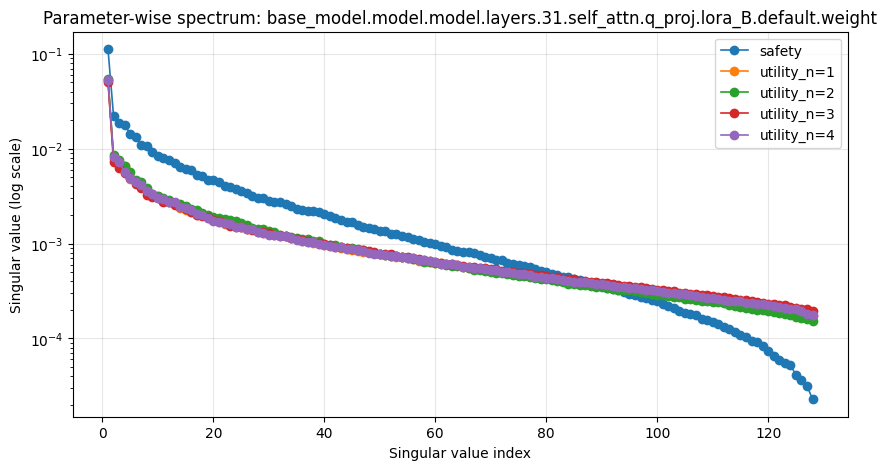

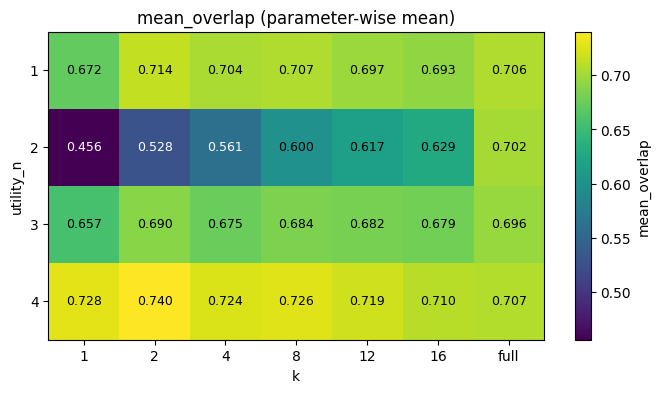

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


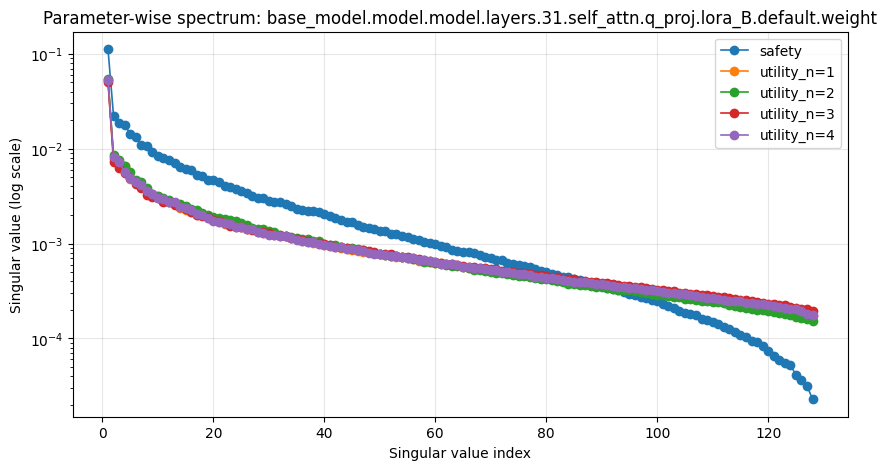

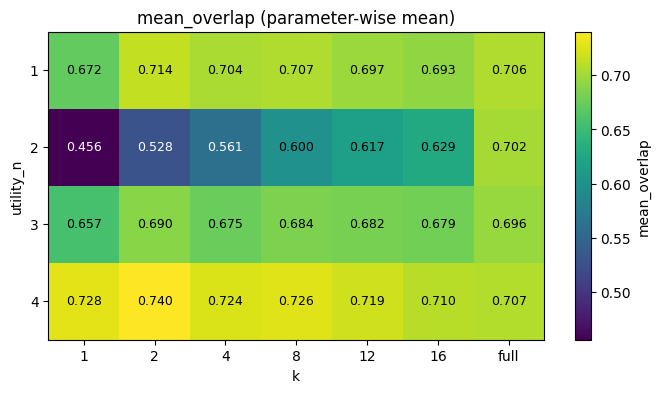

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


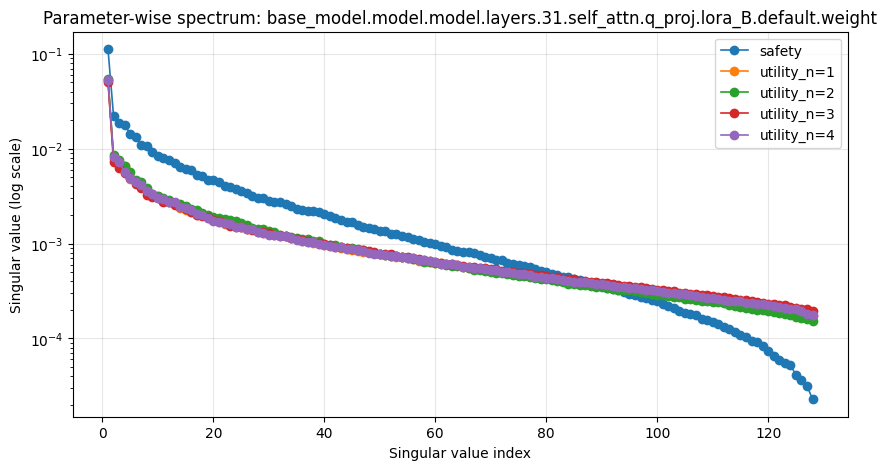

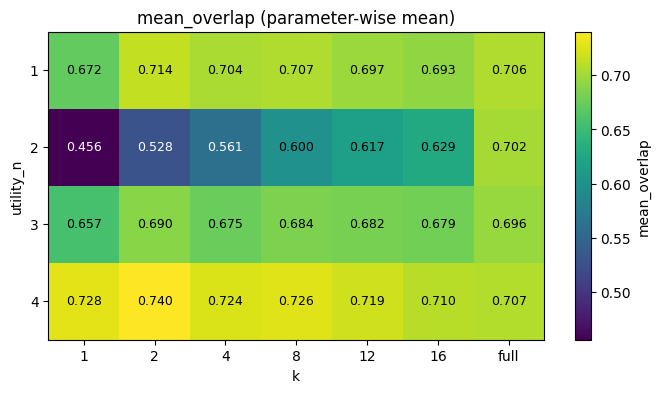

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


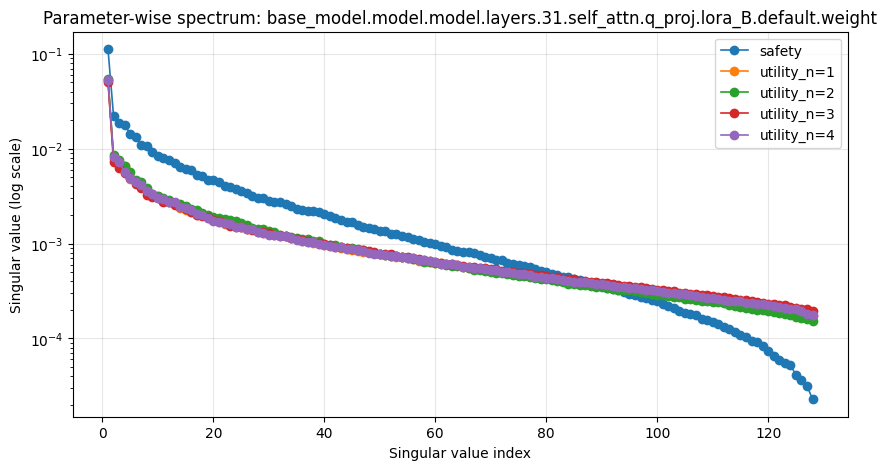

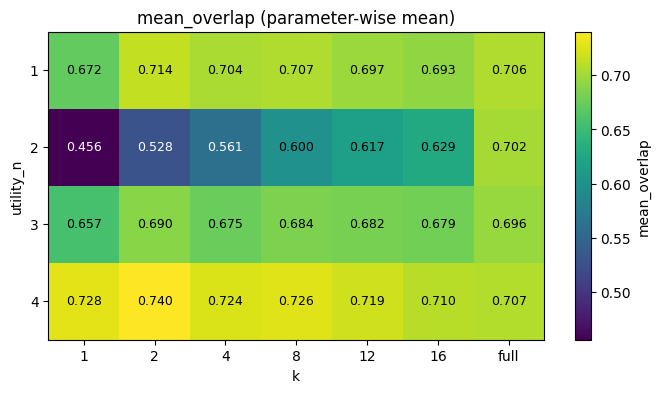

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


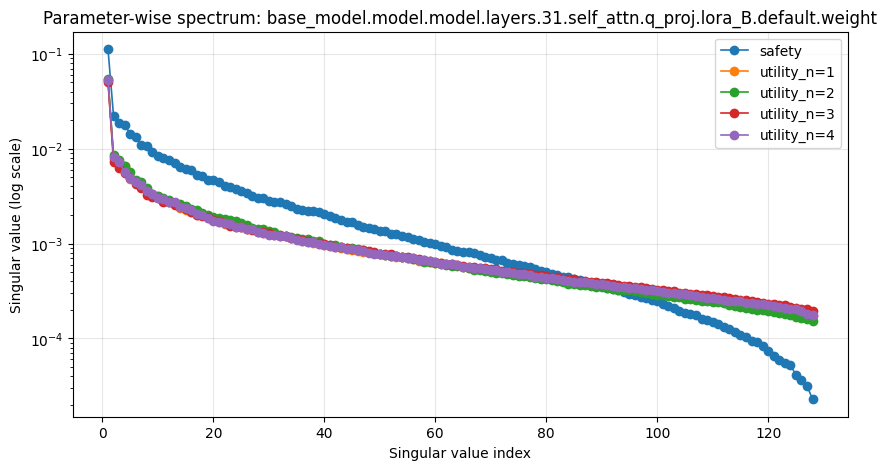

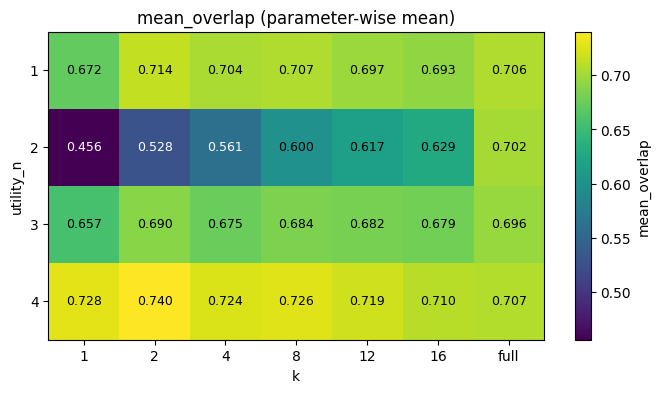

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


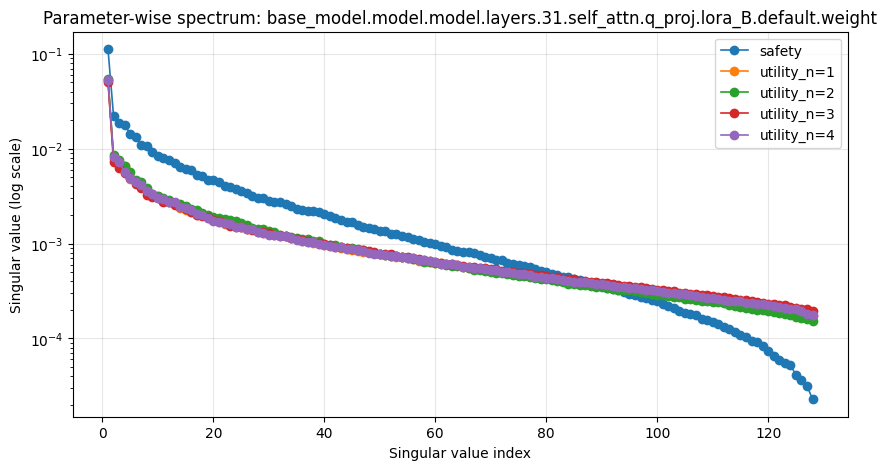

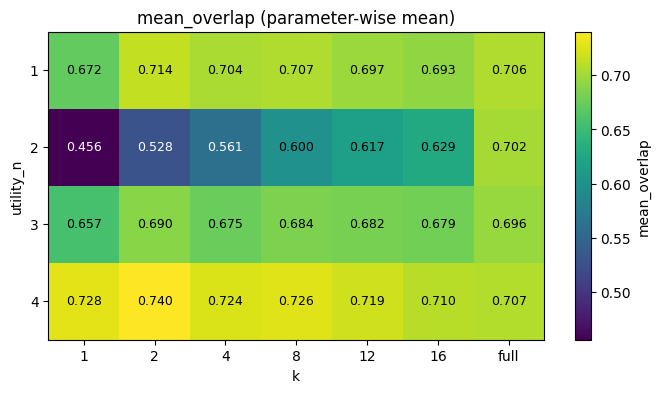

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


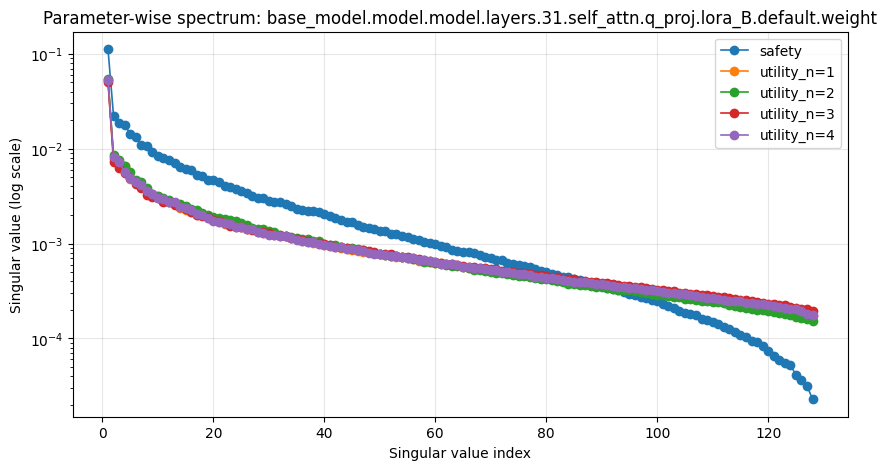

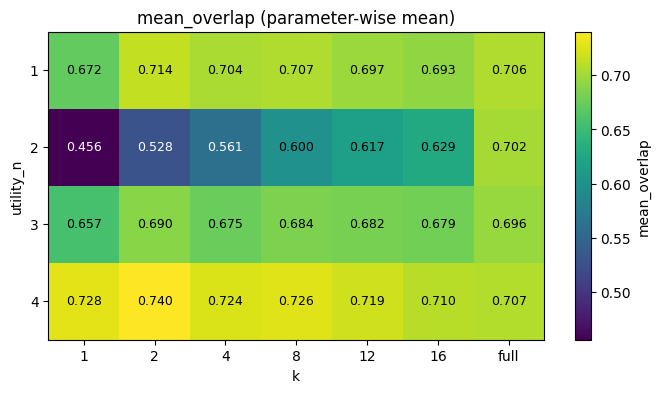

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


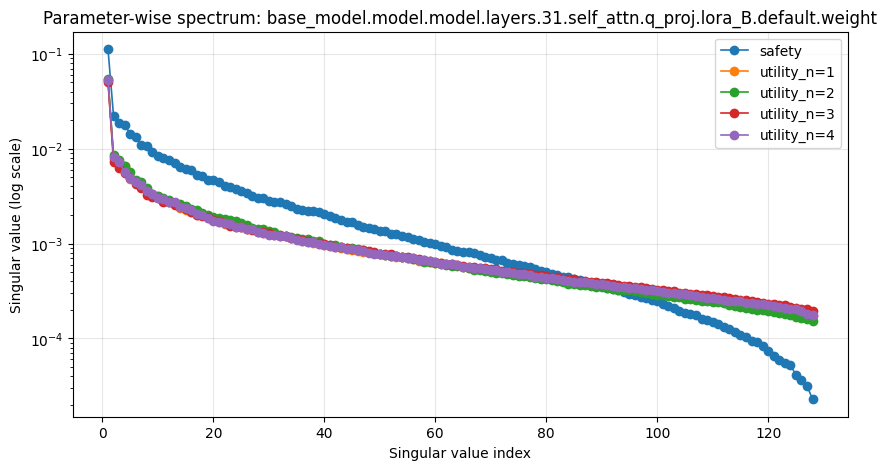

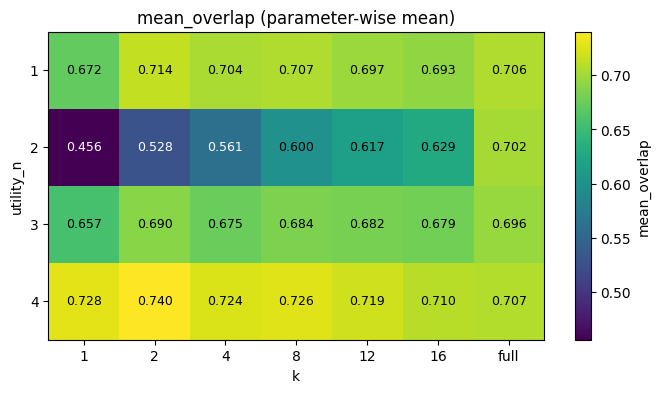

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


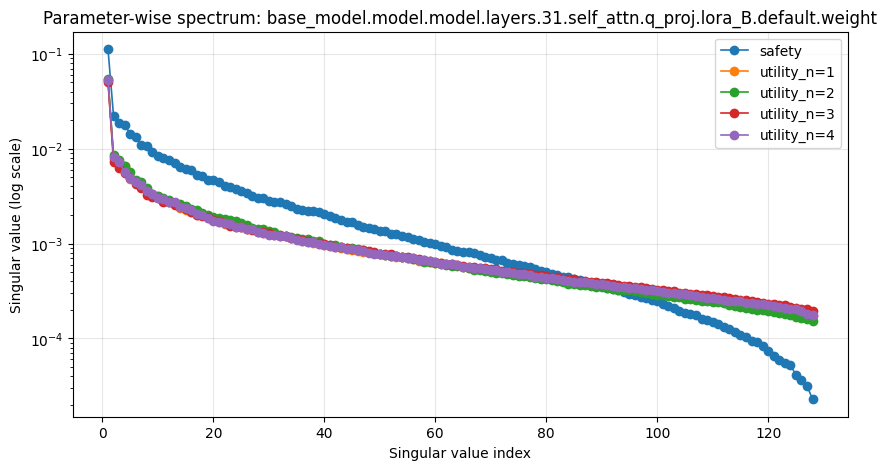

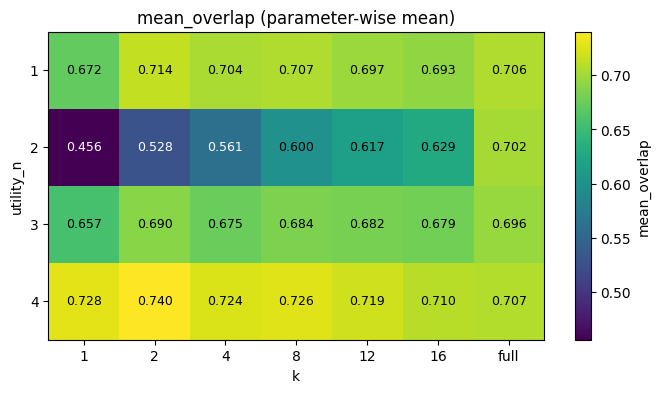

Showing parameter spectrum for: base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight


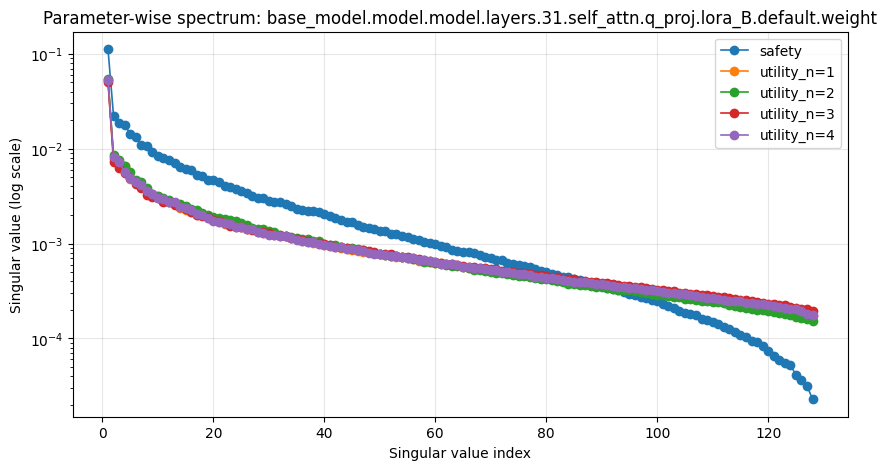

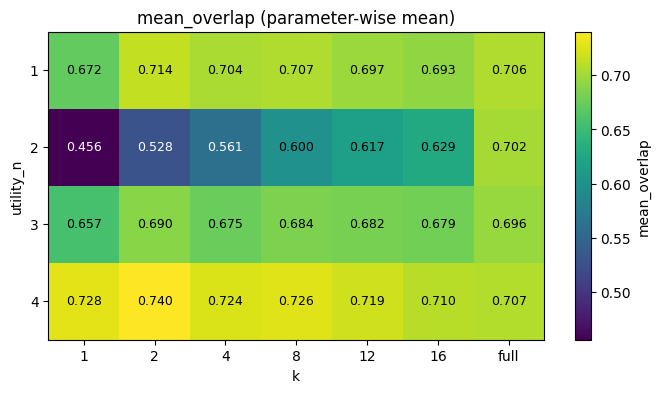

Top conflicting parameters (full-rank overlap formula):


,utility_n,param,conflict
0,1,base_model.model.model.layers.10.self_attn.q_p...,1.000000
1,1,base_model.model.model.layers.18.self_attn.v_p...,1.000000
2,1,base_model.model.model.layers.23.self_attn.q_p...,1.000000
3,1,base_model.model.model.layers.13.self_attn.q_p...,1.000000
4,1,base_model.model.model.layers.15.self_attn.v_p...,1.000000
5,1,base_model.model.model.layers.17.self_attn.v_p...,1.000000
6,1,base_model.model.model.layers.19.self_attn.q_p...,1.000000
7,1,base_model.model.model.layers.19.self_attn.v_p...,1.000000
8,1,base_model.model.model.layers.2.self_attn.v_pr...,1.000000
9,1,base_model.model.model.layers.20.self_attn.v_p...,1.000000


Summary overlap/conflict across parameters:


,utility_n,k_requested,mean_overlap,mean_conflict,median_overlap,median_conflict
0,1,1,0.672322,0.672322,0.694032,0.694032
1,1,2,0.714327,0.714327,0.713164,0.713164
2,1,4,0.703618,0.703618,0.714615,0.714615
3,1,8,0.706549,0.706549,0.724176,0.724176
4,1,12,0.697440,0.697440,0.702793,0.702793
5,1,16,0.692737,0.692737,0.690846,0.690846
6,1,full,0.705808,0.705808,0.783837,0.783837
7,2,1,0.456024,0.456024,0.372065,0.372065
8,2,2,0.528218,0.528218,0.495328,0.495328
9,2,4,0.560664,0.560664,0.607336,0.607336


Spectrum breadth metrics (lower s1_over_sum / higher effective_rank = broader):


,condition,utility_n,param,rank,effective_rank,s1_over_sum
0,safety,0,base_model.model.model.layers.0.self_attn.q_pr...,128,5.432157,0.584524
1,safety,0,base_model.model.model.layers.0.self_attn.q_pr...,128,17.421463,0.242982
2,safety,0,base_model.model.model.layers.0.self_attn.v_pr...,128,1.782631,0.872808
3,safety,0,base_model.model.model.layers.0.self_attn.v_pr...,128,6.071449,0.561099
4,safety,0,base_model.model.model.layers.1.self_attn.q_pr...,128,10.887922,0.360547
...,...,...,...,...,...,...
635,utility_n=4,4,base_model.model.model.layers.8.self_attn.v_pr...,128,23.950704,0.353867
636,utility_n=4,4,base_model.model.model.layers.9.self_attn.q_pr...,128,33.675300,0.192769
637,utility_n=4,4,base_model.model.model.layers.9.self_attn.q_pr...,128,57.263515,0.165876
638,utility_n=4,4,base_model.model.model.layers.9.self_attn.v_pr...,128,11.048900,0.550816


In [13]:
def pick_default_param(param_names: List[str]) -> str:
    lora_b = [p for p in param_names if "lora_B" in p]
    if lora_b:
        return lora_b[0]
    return param_names[0]


def plot_param_spectrum(param_name: str, spectra_by_condition: Dict[str, Dict[str, torch.Tensor]]):
    plt.figure(figsize=(10, 5))
    for cond, by_param in spectra_by_condition.items():
        if param_name not in by_param:
            continue
        vals = by_param[param_name].cpu().numpy()
        x = np.arange(1, len(vals) + 1)
        plt.semilogy(x, vals + 1e-12, marker="o", linewidth=1.2, label=cond)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value (log scale)")
    plt.title(f"Parameter-wise spectrum: {param_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_overlap_heatmap(summary_df: pd.DataFrame, value_col: str):
    # plot_df = summary_df[summary_df["k_requested"] != "full"].copy()
    plot_df = summary_df.copy()
    if len(plot_df) == 0:
        print("No top-k rows available for heatmap.")
        return

    # plot_df["k_requested"] = plot_df["k_requested"].astype(int)

    pivot = plot_df.pivot(index="utility_n", columns="k_requested", values=value_col)

    plt.figure(figsize=(8, 4))
    im = plt.imshow(pivot.values, aspect="auto", cmap="viridis")
    plt.colorbar(im, label=value_col)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("k")
    plt.ylabel("utility_n")
    plt.title(f"{value_col} (parameter-wise mean)")
    data = pivot.values
    thresh = np.nanmin(data) + (np.nanmax(data) - np.nanmin(data)) / 2.0 if np.isfinite(data).any() else 0.0
    fmt='.3f'
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if not np.isfinite(v):
                continue
            color = "white" if v < thresh else "black"
            plt.text(j, i, format(v, fmt), ha="center", va="center", color=color, fontsize=9)

    plt.show()


all_params = sorted(set.intersection(*[set(v.keys()) for v in param_spectra_by_condition.values()]))
for  i in range(10):
    # PICK RANDOM PARAM
    chosen_param = np.random.choice(all_params)
    chosen_param = 'base_model.model.model.layers.31.self_attn.q_proj.lora_B.default.weight'
    # chosen_param = pick_default_param(all_params)
    print(f"Showing parameter spectrum for: {chosen_param}")
    plot_param_spectrum(chosen_param, param_spectra_by_condition)

    plot_overlap_heatmap(summary_overlap_df, "mean_overlap")
    # plot_overlap_heatmap(summary_overlap_df, "mean_conflict")

top_conflict = (
    overlap_df[overlap_df["k_requested"] == "full"]
    .groupby(["utility_n", "param"], as_index=False)["conflict"].mean()
    .sort_values(["utility_n", "conflict"], ascending=[True, False])
)

print("Top conflicting parameters (full-rank overlap formula):")
display(top_conflict.groupby("utility_n").head(10).reset_index(drop=True))

print("Summary overlap/conflict across parameters:")
display(summary_overlap_df.sort_values(["utility_n", "k_requested"]).reset_index(drop=True))

print("Spectrum breadth metrics (lower s1_over_sum / higher effective_rank = broader):")
display(breadth_df.sort_values(["condition", "param"]).reset_index(drop=True))

## Notes

- Each condition uses **parameter-shaped gradients** (for matrix params, e.g., `d_out x d_in`) directly from `p.grad` after `loss.backward()`.
- For multiple samples, gradients are computed by batches and aggregated using `cfg.grad_aggregation`:
  - `single_batch`: gradient from the first batch only
  - `mean_over_batches`: average of batch gradients across all batches in that condition
- Set `cfg.matrix_only=True` to analyze only matrix-shaped trainable parameters (typical LoRA A/B weights).
- To reduce OOM risk, gradients are accumulated on CPU and per-batch tensors are explicitly deleted; set `cfg.clear_cuda_cache_each_batch=True` if needed (slower but lower peak VRAM).
- Overlap now uses cached SVD left subspaces (`U`) per parameter/condition, so all `k` values reuse the same decomposition instead of recomputing SVD repeatedly.
- Overlap formula on left singular vectors:
  $$
  \phi\left(g_s, g_u\right)=\frac{\left\|U_s^\top U_u\right\|_F^2}{\min\left(\operatorname{rank}(U_s),\operatorname{rank}(U_u)\right)}
  $$
- Conflict is defined as `1 - overlap`.